# **Cours :** INF 5103 Concepts statistiques pour la science des données


**TP –  :**

**Date limite pour remettre votre travail : **

**Modalités de travail:**

1.  Les TDevoirs se feront individuellement sur Python.
2.  La remise des Devoirs doit se faire sur Moodle.
3.  Un retard de remise de $n$ journées va causer la perte de $20 n$ points.  

**Livrable**

Retouner ce fichier avec les cellules remplies.


## Partie 1 : Modèle linéaire pour la régression

**Description des données:**

Les données ont été échantillonnées à partir d’une fonction à deux dimensions $f(x_1, x_2)$ où $x_1$ et $x_2$ sont deux attributs. Elles sont données dans un fichier .CSV contenant 200 instances de données et trois colonnes. Les deux premières colonnes décrivent les attributs $x_1$ et $x_2$ et la troisième colonne décrit la variable cible $y$. 

**Implantation demandée**

En utilisant la programmation avec Python et les fonctions de la librairie `scikit-learn`, on vous demande de réaliser les quatre régressions suivantes:

1.   **Une régression ordinaire** avec une fonction polynômiale d’ordre 10.

2.   **Une régression par crête** (ridge regression) avec une fonction polynômiale d’ordre 10.

3.   **Une régression Lasso** (Lasso regression) avec une fonction polynômiale d’ordre 10

4.   **Une régression Elasticnet** (Elasticnet regression) avec une fonction polynômiale d’ordre 10

Utiliser $80\%$ des données pour l'entrainement et $20\%$ des données pour le test et afficher l'erreur de régression pour chaque modèle.

**Instructions:**

Utiliser les fonctions suivantes pour l'implantation de votre code:

*   `LinearRegression()`, `Ridge`  et `Lasso`, `ElasticNet` (de `sklearn.linear_model`) pour implanter les régressions.

*   `PolynomialFeatures` (de `sklearn.preprocessing`) pour générer les attributs des fonctions polynômiales.

*   `train_test_split` (de `sklearn.model_selection`) pour diviser les données en partie entrainement et partie test.
*   `mean_squared_error` (de `sklearn.metrics`)  pour calculer la moyenne des  écarts pour les différents types de régressions.

La cellule suivante montre comment lire les données du fichier CSV dans un dataFrame et afficher le nuage des données en 3D. 

(200, 3)


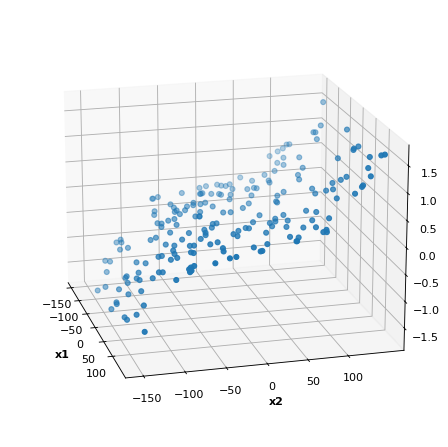

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

SEED = 42

# Lecture des données
df = pd.read_csv('my_data.csv')
print(f"{df.shape}")
X = df.to_numpy()[:,:2]
y = df.to_numpy()[:,2]

# Affichage des données
plt.figure(figsize=(10,7), dpi=80)

ax = plt.axes(projection='3d')
ax.scatter3D(X[:, 0], X[:, 1], y)

ax.set_xlabel('x1',  fontsize=10.0, fontweight='bold')
ax.set_ylabel('x2',  fontsize=10.0, fontweight='bold')
ax.set_zlabel('y',   fontsize=10.0, fontweight='bold')

plt.xticks(np.arange(-150, 150, step=50))
plt.yticks(np.arange(-150, 150, step=50))

ax.view_init(18,-15)

In [9]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
results = []

poly10 = PolynomialFeatures(degree=10, include_bias=False)

x_train_p10 = poly10.fit_transform(x_train)
x_test_p10 = poly10.transform(x_test)

**Une régression ordinaire**

In [10]:
reg_ord = LinearRegression()

reg_ord.fit(x_train_p10, y_train)

x_pred_reg_ord = reg_ord.predict(x_test_p10)

mse_reg_ord = mean_squared_error(y_test, x_pred_reg_ord)
print(f"mse_reg_ord: {mse_reg_ord}")
results.append({"name": "régression ordinaire", "MSE": mse_reg_ord})

mse_reg_ord: 5045886614027.185


**Une régression par crête**

In [11]:
ridge = Ridge(random_state=SEED)

ridge.fit(x_train_p10, y_train)

x_pred_ridge = ridge.predict(x_test_p10)

mse_ridge = mean_squared_error(y_test, x_pred_ridge)
print(f"mse_ridge: {mse_ridge}")
results.append({"name": "ridge", "MSE": mse_ridge})

mse_ridge: 0.06483023675466254


c:\Users\vicgo\Desktop\DESS SDIA\Mardi\INF5103 - Concepts statistiques pour la science des données\Devoir\concept-stat-projet-1\.venv\lib\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=5.89229e-42): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


**Une régression LASSO**

In [12]:
lasso = Lasso(random_state=SEED)

lasso.fit(x_train_p10, y_train)

x_pred_lasso = lasso.predict(x_test_p10)

mse_lasso = mean_squared_error(y_test, x_pred_lasso)
print(f"mse_lasso: {mse_lasso}")
results.append({"name": "LASSO", "MSE": mse_lasso})

mse_lasso: 14101132766.076635


**Une régression Elasticnet** 

In [13]:
elasticnet = ElasticNet(random_state=SEED)

elasticnet.fit(x_train_p10, y_train)

x_pred_elasticnet = elasticnet.predict(x_test_p10)

mse_elasticnet = mean_squared_error(y_test, x_pred_elasticnet)
print(f"mse_elasticnet: {mse_elasticnet}")
results.append({"name": "ElasticNet", "MSE": mse_elasticnet})

mse_elasticnet: 14091909423.324991


## Partie II  : Classification

**Description des données:**

La description est sur le site : https://archive.ics.uci.edu/ml/datasets/Spambase 

L’ensemble des données contient 4601 instances d’emails. Chaque email est décrit par 57 attributs dans R calculé sur le texte de l’email.   

*  48 attributs représentant les fréquences mots (ex. internet, money, etc.)   
*  06 attributs représentant les fréquences de caractères spéciaux (ex. ;, \$, etc.).
 etc.)
*  03 attributs de statistiques sur la longueur de séquences en majuscules. 
*  La dernière colonne donne l’étiquette de la classe (1 : spam, 0 : ham).


**Implantation demandée**

Utiliser une validation croisée en $m=3$ plis, et donner pour chaque algorithme l’erreur de validation moyenne.
 
*   Classificateur de Bayes
*   Régression logistique
*   Réseaux de neurones

**Instructions:**

1) Utiliser les fonctions de Pandas pour résumer les statistiques importantes de l'ensemble des données. 

2) Utiliser les fonctions suivantes pour l'implantation de votre code:


*   `GaussianNB` (de `sklearn.naive_bayes.GaussianNB`) pour implanter le classifieur de Bayes.

*  `LogisticRegression` (de `sklearn.linear_model.LogisticRegression`) pour implanter la régression logistique.

*  `MLPClassifier` (de `sklearn.neural_network`) pour implanter les réseaux de neurones.

*   `cross_validate` (de `sklearn.model_selection`) pour générer la validation croisée en utilisant les plis.



In [14]:
import pandas as pd
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from ucimlrepo import fetch_ucirepo

# ── Chargement des données Spambase via ucimlrepo ──────────────────────────
spambase = fetch_ucirepo(id=94)

X_data = spambase.data.features
y_data = spambase.data.targets

# Reconstruction du DataFrame complet pour les statistiques descriptives
spam_df = X_data.copy()
spam_df['spam'] = y_data.values

# ── Statistiques descriptives ──────────────────────────────────────────────
print(f"Dimensions des données : {spam_df.shape}")
print(f"\nDistribution des classes:\n{spam_df['spam'].value_counts().rename({0: 'ham (0)', 1: 'spam (1)'})}")
print(f"\nStatistiques descriptives (premières colonnes):")
print(spam_df.describe().iloc[:, :5])

# ── Préparation des données ────────────────────────────────────────────────
X_spam = X_data.values
y_spam = y_data.values.ravel()

m = 3  # nombre de plis

# ── 1. Classificateur de Bayes naïf (Gaussien) ────────────────────────────
gnb = GaussianNB()
scores_gnb = cross_validate(gnb, X_spam, y_spam, cv=m, scoring='accuracy')
err_gnb = 1 - scores_gnb['test_score'].mean()
print(f"\n--- Validation croisée (m={m} plis) ---")
print(f"Classificateur de Bayes    - Erreur moyenne : {err_gnb:.4f}  "
      f"({scores_gnb['test_score'].mean()*100:.2f}% précision)")

# ── 2. Régression logistique ──────────────────────────────────────────────
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(max_iter=1000, random_state=42))
])
scores_lr = cross_validate(lr_pipe, X_spam, y_spam, cv=m, scoring='accuracy')
err_lr = 1 - scores_lr['test_score'].mean()
print(f"Régression logistique      - Erreur moyenne : {err_lr:.4f}  "
      f"({scores_lr['test_score'].mean()*100:.2f}% précision)")

# ── 3. Réseau de neurones (MLP) ────────────────────────────────────────────
mlp_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp',    MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42))
])
scores_mlp = cross_validate(mlp_pipe, X_spam, y_spam, cv=m, scoring='accuracy')
err_mlp = 1 - scores_mlp['test_score'].mean()
print(f"Réseau de neurones (MLP)   - Erreur moyenne : {err_mlp:.4f}  "
      f"({scores_mlp['test_score'].mean()*100:.2f}% précision)")

Dimensions des données : (4601, 58)

Distribution des classes:
spam
ham (0)     2788
spam (1)    1813
Name: count, dtype: int64

Statistiques descriptives (premières colonnes):
       word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
count     4601.000000        4601.000000    4601.000000   4601.000000   
mean         0.104553           0.213015       0.280656      0.065425   
std          0.305358           1.290575       0.504143      1.395151   
min          0.000000           0.000000       0.000000      0.000000   
25%          0.000000           0.000000       0.000000      0.000000   
50%          0.000000           0.000000       0.000000      0.000000   
75%          0.000000           0.000000       0.420000      0.000000   
max          4.540000          14.280000       5.100000     42.810000   

       word_freq_our  
count    4601.000000  
mean        0.312223  
std         0.672513  
min         0.000000  
25%         0.000000  
50%         0.000000  
75% 

## Introduction à la classification de courriels indésirables

### Les données : Spambase (UCI Machine Learning Repository)

L'ensemble de données utilisé est le jeu de données **Spambase**, disponible sur le [répertoire UCI Machine Learning](https://archive.ics.uci.edu/ml/datasets/Spambase). Il contient **4 601 courriels** réels, chacun décrit par **57 attributs numériques** extraits du contenu textuel :

- **48 attributs** : fréquence relative (en %) de certains mots-clés dans le courriel (ex. *money*, *free*, *internet*, *credit*…).
- **6 attributs** : fréquence relative de caractères spéciaux (ex. `!`, `$`, `#`…).
- **3 attributs** : statistiques sur les séquences de lettres majuscules (longueur moyenne, longueur maximale, nombre total).
- **1 étiquette de classe** : `1` pour *spam*, `0` pour *ham*.

### Qu'est-ce que le *spam* et le *ham* ?

| Étiquette | Valeur | Signification |
|-----------|--------|---------------|
| **Ham**   | `0`    | Courriel **légitime**, envoyé volontairement et attendu par le destinataire. |
| **Spam**  | `1`    | Courriel **indésirable** (publicité non sollicitée, hameçonnage, arnaque, etc.). |

Dans cet ensemble de données, **2 788 courriels (60,6 %)** sont des ham et **1 813 (39,4 %)** sont des spam.

### But des algorithmes de classification

L'objectif est d'entraîner un modèle capable de **distinguer automatiquement** un courriel indésirable (spam) d'un courriel légitime (ham) à partir de ses 57 attributs, sans lire le contenu brut du message.

Trois algorithmes sont comparés à l'aide d'une **validation croisée à 3 plis** (*3-fold cross-validation*), ce qui permet d'estimer l'erreur de généralisation de manière robuste :

1. **Classificateur de Bayes naïf gaussien** — modèle probabiliste simple qui suppose l'indépendance conditionnelle des attributs.
2. **Régression logistique** — modèle linéaire qui estime la probabilité d'appartenance à chaque classe.
3. **Réseau de neurones (MLP)** — modèle non linéaire composé de couches de neurones artificiels, capable de capturer des relations complexes entre les attributs.